# `code_metrics`의 구현을 해부한다

```python
@torch.no_grad()
def code_metrics(q, labels):
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    return top_share, correct / len(labels)
```

이 다섯 줄이 **왜 그렇게 쓰여 있는지**를 텐서 단위로 따라간다.
`code_acc`가 "군집 순도"라는 개념적 의미는 여기서 다루지 않는다. 여기서 볼 것은 네 가지다.

1. 중간 텐서를 손으로 따라가기 — `codes` → `counts` → `unique()` → 코드별 `bincount()`
2. `minlength`가 **있는** 자리와 **없는** 자리, 각각의 이유
3. `codes.unique()`가 `range(out_dim)`이 아닌 이유 — 빈 텐서의 `.max()`는 예외를 던진다
4. 파이썬 루프를 confusion matrix 한 방으로 바꾸는 벡터화, 그리고 $K=65536$일 때의 실제 시간차

마지막으로 `argmax`가 버리는 정보(확신도)를 정량화한다.

In [1]:
import math
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)


@torch.no_grad()
def code_metrics(q, labels):
    """원본 그대로."""
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    return top_share, correct / len(labels)


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 손으로 따라가는 예제 — 점 12개, `out_dim=5`, 클러스터 3개

실제 $q$는 teacher 로짓의 softmax지만 여기서는 **argmax 위치만** 중요하므로,
원하는 코드에 로짓을 몰아준 뒤 softmax를 취해 만든다.

의도한 배치:

| 점 | 0 1 2 3 | 4 5 6 7 | 8 9 10 11 |
|---|---|---|---|
| 레이블 | 0 0 0 0 | 1 1 1 1 | 2 2 2 2 |
| 코드 | 0 0 0 **2** | 2 2 2 2 | 3 3 **0** 3 |

점 3은 레이블 0인데 코드 2로, 점 10은 레이블 2인데 코드 0으로 새어 나갔다 — 오분류 재료다.
그리고 코드 1과 4는 **아무도 쓰지 않는다** — 뒤에서 `minlength`와 `unique()` 얘기의 재료가 된다.

In [2]:
N, OUT_DIM = 12, 5
labels = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2])
want = torch.tensor([0, 0, 0, 2, 2, 2, 2, 2, 3, 3, 0, 3])

logits = torch.randn(N, OUT_DIM) * 0.1
logits[torch.arange(N), want] += 5.0          # 원하는 코드를 확실한 argmax로
q = F.softmax(logits / 0.5, dim=-1)

print("q.shape          :", tuple(q.shape))
print("q[0] (반올림)     :", [round(v, 3) for v in q[0].tolist()])
print("q 행합이 1인가    :", torch.allclose(q.sum(-1), torch.ones(N)))

q.shape          : (12, 5)
q[0] (반올림)     : [1.0, 0.0, 0.0, 0.0, 0.0]
q 행합이 1인가    : True


### 1-1. `codes = q.argmax(-1)`

$(N, K)$ 확률 행렬이 $(N,)$ 정수 벡터로 납작해진다. 각 점이 **어느 prototype에 속하는지**만 남는다.

In [3]:
codes = q.argmax(-1)
print("codes  :", codes.tolist())
print("dtype  :", codes.dtype, " shape:", tuple(codes.shape))
print("의도대로:", torch.equal(codes, want))

codes  : [0, 0, 0, 2, 2, 2, 2, 2, 3, 3, 0, 3]
dtype  : torch.int64  shape: (12,)
의도대로: True


### 1-2. `counts = codes.bincount(minlength=q.shape[-1])` → `top_share`

`bincount`는 "값 $j$가 몇 번 나왔나"를 인덱스 $j$에 담는다. 즉 **코드 사용량 히스토그램**이다.

$$\texttt{top\_share} = \frac{\max_c \#\{i : \texttt{codes}_i = c\}}{N}$$

원-핫 붕괴면 코드 하나가 전부를 먹어 $1.0$에 붙고, 건강하면 $1/(\text{쓰이는 코드 수})$ 근처에 앉는다.

In [4]:
counts = codes.bincount(minlength=q.shape[-1])
print("counts        :", counts.tolist(), "  (인덱스=코드, 값=점 개수)")
print("counts.sum()  :", counts.sum().item(), "= N")
print("가장 붐비는 코드:", counts.argmax().item(), "→", counts.max().item(), "개")
print("top_share     :", counts.max().item() / len(codes))

counts        : [4, 0, 5, 3, 0]   (인덱스=코드, 값=점 개수)
counts.sum()  : 12 = N
가장 붐비는 코드: 2 → 5 개
top_share     : 0.4166666666666667


### 1-3. `correct = sum(labels[codes == c].bincount().max() for c in codes.unique())`

코드 하나를 뽑아 → 그 코드에 속한 점들의 **레이블만** 모아 → 최빈 레이블의 개수를 센다.
"그 코드가 다수결로 찍었을 때 맞히는 개수"다. 코드마다 더해서 $N$으로 나누면 정확도.

In [5]:
uniq = codes.unique()
print("codes.unique():", uniq.tolist(), "  ← 실제 등장한 코드만. 1, 4는 없다")
print()
total = 0
for c in uniq.tolist():
    mask = codes == c
    sub = labels[mask]
    bc = sub.bincount()
    total += bc.max().item()
    print(f"코드 {c}: mask               = {mask.int().tolist()}")
    print(f"        labels[codes=={c}]  = {sub.tolist()}")
    print(f"        .bincount()        = {bc.tolist()}  (인덱스=레이블)")
    print(f"        .max()             = {bc.max().item()}  (다수 레이블 {bc.argmax().item()})")
print()
print("correct  :", total, " ← 3 + 4 + 3")
print("code_acc :", total / len(labels))
print("원본 함수:", code_metrics(q, labels))

codes.unique(): [0, 2, 3]   ← 실제 등장한 코드만. 1, 4는 없다

코드 0: mask               = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
        labels[codes==0]  = [0, 0, 0, 2]
        .bincount()        = [3, 0, 1]  (인덱스=레이블)
        .max()             = 3  (다수 레이블 0)
코드 2: mask               = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
        labels[codes==2]  = [0, 1, 1, 1, 1]
        .bincount()        = [1, 4]  (인덱스=레이블)
        .max()             = 4  (다수 레이블 1)
코드 3: mask               = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
        labels[codes==3]  = [2, 2, 2]
        .bincount()        = [0, 0, 3]  (인덱스=레이블)
        .max()             = 3  (다수 레이블 2)

correct  : 10  ← 3 + 4 + 3
code_acc : 0.8333333333333334
원본 함수: (0.4166666666666667, 0.8333333333333334)


점 3(코드 2의 레이블 0)과 점 10(코드 0의 레이블 2)이 각각 다수결에서 밀려 2개를 틀렸다. $10/12 = 0.833$.

## 2. `minlength`는 무엇을 지키는가

`bincount`의 결과 길이는 기본적으로 `max(values) + 1`이다.
즉 **마지막 코드들이 안 쓰이면 배열이 짧아진다**. 위 예제에서 최대 코드는 3이므로
`minlength` 없이는 길이 4가 되어 코드 4가 통째로 사라진다.

In [6]:
short = codes.bincount()
full = codes.bincount(minlength=q.shape[-1])
print("minlength 없음:", short.tolist(), " len =", len(short))
print("minlength=5   :", full.tolist(), " len =", len(full))
print()
print("top_share 값은 같은가:", short.max().item() == full.max().item())
print("  → .max()만 쓰므로 지표 값 자체는 안 바뀐다. 여기서는 순수하게 방어적이다.")
print()
print("하지만 counts를 '길이 K의 벡터'로 취급하는 순간 깨진다:")
try:
    short[4]
except IndexError as e:
    print("  short[4] (코드 4 사용량 조회) →", type(e).__name__, ":", e)
print("  full[4] :", full[4].item(), " ← 0. 이게 정답")

minlength 없음: [4, 0, 5, 3]  len = 4
minlength=5   : [4, 0, 5, 3, 0]  len = 5

top_share 값은 같은가: True
  → .max()만 쓰므로 지표 값 자체는 안 바뀐다. 여기서는 순수하게 방어적이다.

하지만 counts를 '길이 K의 벡터'로 취급하는 순간 깨진다:
  short[4] (코드 4 사용량 조회) → IndexError : index 4 is out of bounds for dimension 0 with size 4
  full[4] : 0  ← 0. 이게 정답


### 스텝 간 비교를 하면 바로 터진다

학습 로그를 찍는 상황을 생각하자. 스텝마다 `counts`를 쌓아 $(\text{steps}, K)$ 행렬을 만들고 싶은데,
`minlength`가 없으면 스텝마다 길이가 달라져 `torch.stack`이 실패한다.
코드 사용량 히스토그램을 애니메이션으로 그리거나 스텝별 사용률 변화를 보려면 길이 고정이 **필수**다.

In [7]:
step_a = torch.tensor([0, 0, 1, 1, 4, 4])        # 코드 4까지 씀
step_b = torch.tensor([0, 0, 1, 1, 2, 2])        # 코드 2까지만 씀
try:
    torch.stack([step_a.bincount(), step_b.bincount()])
except RuntimeError as e:
    print("minlength 없이 stack →", type(e).__name__)
    print("  ", str(e).split("\n")[0])
ok = torch.stack([step_a.bincount(minlength=5), step_b.bincount(minlength=5)])
print("minlength=5로 stack → shape", tuple(ok.shape))
print(ok.tolist())

minlength 없이 stack → RuntimeError
   stack expects each tensor to be equal size, but got [5] at entry 0 and [3] at entry 1
minlength=5로 stack → shape (2, 5)
[[2, 2, 0, 0, 2], [2, 2, 2, 0, 0]]


## 3. `labels[...].bincount()`의 함정 네 가지

### 3-1. 레이블이 0-기반 연속 정수가 아니면 낭비, 음수면 에러

`bincount`는 **값을 인덱스로** 쓴다. 그래서 레이블 집합의 모양이 그대로 배열 크기가 된다.

In [8]:
lab0 = torch.tensor([0, 0, 1, 1, 1])            # 0-기반
lab1 = lab0 + 1                                  # 1..2 로 시프트
lab_big = torch.tensor([100, 100, 357, 357, 357])
print("0-기반  ", lab0.tolist(), "→ bincount", lab0.bincount().tolist(), " len", len(lab0.bincount()))
print("1-기반  ", lab1.tolist(), "→ bincount", lab1.bincount().tolist(), " len", len(lab1.bincount()), " ← 0번 칸이 낭비")
print("희소 id ", lab_big.tolist(), "→ len", len(lab_big.bincount()), " ← 358칸 중 2칸만 씀")
print()
print("하지만 .max()는 모두 3으로 같다:",
      lab0.bincount().max().item(), lab1.bincount().max().item(), lab_big.bincount().max().item())

0-기반   [0, 0, 1, 1, 1] → bincount [2, 3]  len 2
1-기반   [1, 1, 2, 2, 2] → bincount [0, 2, 3]  len 3  ← 0번 칸이 낭비
희소 id  [100, 100, 357, 357, 357] → len 358  ← 358칸 중 2칸만 씀

하지만 .max()는 모두 3으로 같다: 3 3 3


낭비가 값을 바꾸지는 않지만 **할당은 실제로 일어난다**. ImageNet-1k 레이블(0..999)이라면
코드마다 1000칸짜리 배열을 새로 만든다는 뜻이고, 코드가 65536개면 그 할당이 수만 번 반복된다 (§5의 동기).

### 3-2. 음수 레이블은 즉사

In [9]:
lab_neg = torch.tensor([-1, -1, 0, 0, 0])       # 예: unlabeled를 -1로 표기
try:
    lab_neg.bincount()
except RuntimeError as e:
    print("음수 레이블 → ", type(e).__name__, ":", str(e).split("\n")[0])
print("→ -1을 ignore_index로 쓰는 관행과 code_metrics는 그대로는 호환되지 않는다")

음수 레이블 →  RuntimeError : bincount only supports 1-d non-negative integral inputs.
→ -1을 ignore_index로 쓰는 관행과 code_metrics는 그대로는 호환되지 않는다


### 3-3. 여기 `bincount`에는 `minlength`가 없다 — 그리고 그래도 된다

`counts` 쪽과 달리 이 `bincount`는 결과를 **길이로 쓰지 않고** `.max()`만 취한다.
뒤쪽 레이블이 이 코드에 하나도 없어서 배열이 짧아져도 최빈값 개수는 변하지 않는다.

In [10]:
sub = labels[codes == 0]                        # [0, 0, 0, 2]
print("sub                       :", sub.tolist())
print("bincount()                :", sub.bincount().tolist())
print("bincount(minlength=3)     :", sub.bincount(minlength=3).tolist())
print("bincount(minlength=1000)  : len", len(sub.bincount(minlength=1000)))
print(".max() 전부 동일          :",
      sub.bincount().max().item(),
      sub.bincount(minlength=3).max().item(),
      sub.bincount(minlength=1000).max().item())
print("→ 뒤에 0을 아무리 붙여도 최댓값은 그대로. minlength가 없는 게 버그가 아니다.")

sub                       : [0, 0, 0, 2]
bincount()                : [3, 0, 1]
bincount(minlength=3)     : [3, 0, 1]
bincount(minlength=1000)  : len 1000
.max() 전부 동일          : 3 3 3
→ 뒤에 0을 아무리 붙여도 최댓값은 그대로. minlength가 없는 게 버그가 아니다.


### 3-4. 동점(tie)은 신경 쓸 필요가 없다

한 코드 안에서 두 레이블이 같은 개수라면 `.max()`가 "어느 레이블"을 고르는지는 임의다
(`.argmax()`는 첫 번째를 준다). 하지만 우리가 쓰는 건 **개수**뿐이므로 결과는 유일하다.

In [11]:
tie = torch.tensor([0, 0, 1, 1])                # 0과 1이 2개씩
print("tie labels     :", tie.tolist())
print("bincount       :", tie.bincount().tolist())
print("argmax (임의)  :", tie.bincount().argmax().item(), " ← 첫 번째 최대를 고른다")
print("max    (유일)  :", tie.bincount().max().item(), " ← 이것만 쓰므로 무해")
rev = torch.tensor([1, 1, 0, 0])
print("순서를 뒤집어도 max는:", rev.bincount().max().item(), " (argmax는", rev.bincount().argmax().item(), ")")

tie labels     : [0, 0, 1, 1]
bincount       : [2, 2]
argmax (임의)  : 0  ← 첫 번째 최대를 고른다
max    (유일)  : 2  ← 이것만 쓰므로 무해
순서를 뒤집어도 max는: 2  (argmax는 0 )


## 4. 왜 `codes.unique()`이고 `range(out_dim)`이 아닌가

`unique()`는 **실제로 등장한** 코드만 준다. 그래서 `labels[codes == c]`가 빈 텐서가 되는 일이 없다.
`range(out_dim)`으로 돌면 안 쓰인 코드(위 예제의 1과 4)에서 빈 텐서의 `.max()`를 부르게 되고 —

In [12]:
empty = labels[codes == 1]                      # 코드 1은 아무도 안 씀
print("labels[codes == 1] :", empty.tolist(), " shape", tuple(empty.shape))
print("빈 텐서 bincount   :", empty.bincount().tolist(), " shape", tuple(empty.bincount().shape))
try:
    empty.bincount().max()
except (RuntimeError, IndexError) as e:
    print("빈 텐서 .max()     →", type(e).__name__, ":", str(e).split("\n")[0])

labels[codes == 1] : []  shape (0,)
빈 텐서 bincount   : []  shape (0,)
빈 텐서 .max()     → RuntimeError : max(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.


In [13]:
# range(out_dim)으로 돌면 실제로 터진다
def code_metrics_broken(q, labels):
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in range(q.shape[-1]))
    return top_share, correct / len(labels)


try:
    code_metrics_broken(q, labels)
except RuntimeError as e:
    print("range(out_dim) 버전 →", type(e).__name__)
    print("  ", str(e).split("\n")[0])
print()
print("unique() 버전 :", code_metrics(q, labels))
print("→ DINO는 out_dim=65536인데 실제로 쓰이는 코드는 그중 일부다.")
print("  빈 코드는 예외가 아니라 규칙이므로 unique()는 선택이 아니라 필수다.")

range(out_dim) 버전 → RuntimeError
   max(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.

unique() 버전 : (0.4166666666666667, 0.8333333333333334)
→ DINO는 out_dim=65536인데 실제로 쓰이는 코드는 그중 일부다.
  빈 코드는 예외가 아니라 규칙이므로 unique()는 선택이 아니라 필수다.


## 5. 벡터화 — 루프를 confusion matrix 한 번으로

루프가 하는 일은 결국 **코드 × 레이블 분할표**를 코드별로 한 줄씩 만드는 것이다.
그렇다면 표 전체를 한 번에 만들면 된다.

$$M_{c\ell} = \#\{i : \texttt{codes}_i = c,\ \texttt{labels}_i = \ell\},\qquad
\texttt{correct} = \sum_c \max_\ell M_{c\ell}$$

빈 코드의 행은 전부 0이고 그 행의 `max`도 0이므로 합에 기여하지 않는다 — §4의 예외가 **자동으로 사라진다**.
`index_put_(..., accumulate=True)`가 산포 누적을 해 준다.

In [14]:
@torch.no_grad()
def code_metrics_vec(q, labels, n_labels=None):
    codes = q.argmax(-1)
    n_codes = q.shape[-1]
    n_labels = int(labels.max().item()) + 1 if n_labels is None else n_labels
    counts = codes.bincount(minlength=n_codes)
    top_share = counts.max().item() / len(codes)

    conf = torch.zeros(n_codes, n_labels)
    conf.index_put_((codes, labels), torch.ones(len(codes)), accumulate=True)
    correct = conf.max(dim=1).values.sum().item()
    return top_share, correct / len(labels), conf


@torch.no_grad()
def code_metrics_scatter(q, labels, n_labels=None):
    """같은 표를 scatter_add_ 로. flat index → 1D 누적 → reshape."""
    codes = q.argmax(-1)
    n_codes = q.shape[-1]
    n_labels = int(labels.max().item()) + 1 if n_labels is None else n_labels
    counts = codes.bincount(minlength=n_codes)
    top_share = counts.max().item() / len(codes)

    flat = torch.zeros(n_codes * n_labels)
    flat.scatter_add_(0, codes * n_labels + labels, torch.ones(len(codes)))
    conf = flat.view(n_codes, n_labels)
    correct = conf.max(dim=1).values.sum().item()
    return top_share, correct / len(labels), conf


ts_ref, acc_ref = code_metrics(q, labels)
ts_v, acc_v, conf_toy = code_metrics_vec(q, labels)
ts_s, acc_s, _ = code_metrics_scatter(q, labels)
print("원본        :", (ts_ref, acc_ref))
print("index_put_  :", (ts_v, acc_v))
print("scatter_add_:", (ts_s, acc_s))
print("일치        :", (ts_ref, acc_ref) == (ts_v, acc_v) == (ts_s, acc_s))
print()
print("confusion matrix (행=코드 0..4, 열=레이블 0..2):")
for i, row in enumerate(conf_toy.int().tolist()):
    print(f"  코드 {i}: {row}   max = {max(row)}")
print("행별 max 합 =", int(conf_toy.max(dim=1).values.sum()), " ← correct")
print("빈 코드 1, 4의 행은 전부 0이라 자동으로 무시된다 — try/except가 필요 없다")

원본        : (0.4166666666666667, 0.8333333333333334)
index_put_  : (0.4166666666666667, 0.8333333333333334)
scatter_add_: (0.4166666666666667, 0.8333333333333334)
일치        : True

confusion matrix (행=코드 0..4, 열=레이블 0..2):
  코드 0: [3, 0, 1]   max = 3
  코드 1: [0, 0, 0]   max = 0
  코드 2: [1, 4, 0]   max = 4
  코드 3: [0, 0, 3]   max = 3
  코드 4: [0, 0, 0]   max = 0
행별 max 합 = 10  ← correct
빈 코드 1, 4의 행은 전부 0이라 자동으로 무시된다 — try/except가 필요 없다


### 5-1. DINO 규모에서 재보기 — $K = 65536$

루프 버전은 `codes.unique()` 길이 $U$만큼 반복하고, **반복마다** 길이 $N$의 불리언 마스크와
고급 인덱싱과 새 `bincount` 배열을 만든다. 즉 $O(U \cdot N)$이다.
벡터화 버전은 $O(N + K \cdot L)$ 한 번이다.

두 버전 모두 `argmax`는 똑같이 한 번 하므로, 차이가 나는 뒷부분(`correct` 계산)만 잰다.
참고로 $q$를 실제로 만들면 $20000 \times 65536$ float $= 5.2$ GB이므로 `codes`를 직접 생성한다 —
실제 DINO 평가도 $q$ 전체를 메모리에 올리지 않는다.

In [15]:
N_BIG, K_BIG, L_BIG = 20000, 65536, 100
g = torch.Generator().manual_seed(1)
codes_big = torch.randint(0, K_BIG, (N_BIG,), generator=g)
labels_big = torch.randint(0, L_BIG, (N_BIG,), generator=g)
U = len(codes_big.unique())
print(f"N={N_BIG}, K={K_BIG}, L={L_BIG}, 실제 쓰인 코드 U={U}")


def correct_loop(codes, labels):
    return sum(labels[codes == c].bincount().max().item() for c in codes.unique())


def correct_index_put(codes, labels, n_codes, n_labels):
    conf = torch.zeros(n_codes, n_labels)
    conf.index_put_((codes, labels), torch.ones(len(codes)), accumulate=True)
    return int(conf.max(dim=1).values.sum().item())


def correct_scatter(codes, labels, n_codes, n_labels):
    flat = torch.zeros(n_codes * n_labels)
    flat.scatter_add_(0, codes * n_labels + labels, torch.ones(len(codes)))
    return int(flat.view(n_codes, n_labels).max(dim=1).values.sum().item())


timings = {}
for name, fn in [("루프 (원본)", lambda: correct_loop(codes_big, labels_big)),
                 ("index_put_", lambda: correct_index_put(codes_big, labels_big, K_BIG, L_BIG)),
                 ("scatter_add_", lambda: correct_scatter(codes_big, labels_big, K_BIG, L_BIG))]:
    t0 = time.perf_counter()
    r = fn()
    timings[name] = (time.perf_counter() - t0, r)
    print(f"{name:14s} {timings[name][0]*1000:9.2f} ms   correct = {r}")

t_loop = timings["루프 (원본)"][0]
print()
print(f"배속: index_put_ {t_loop/timings['index_put_'][0]:.0f}x, "
      f"scatter_add_ {t_loop/timings['scatter_add_'][0]:.0f}x")
print("결과 일치:", len({v[1] for v in timings.values()}) == 1)

N=20000, K=65536, L=100, 실제 쓰인 코드 U=17235
루프 (원본)           946.08 ms   correct = 17268
index_put_          5.91 ms   correct = 17268
scatter_add_        3.72 ms   correct = 17268

배속: index_put_ 160x, scatter_add_ 254x
결과 일치: True


0.96초 대 4~6밀리초 — **150~350배**다. 토이 노트북처럼 $K=32$, $N=768$이면 루프가 더 읽기 쉬워
원본이 옳은 선택이지만, 실제 DINO 설정($K=65536$)에서 25스텝마다 이 지표를 찍는다면
학습 시간의 상당 부분이 평가 루프로 새어 나간다.

> `.item()`이 루프 안에 있다는 점도 CPU에서는 티가 안 나지만 GPU에서는 반복마다 **동기화**를 강제한다.
> 벡터화 버전은 `.item()`을 마지막에 한 번만 호출한다.
> 반면 벡터화는 $K \times L$ 크기의 표를 실제로 할당한다 — $65536 \times 1000$이면 262 MB.
> $L$이 크면 `torch.unique(codes, return_inverse=True)`로 행을 $U$개로 압축하는 게 낫다.

## 6. `argmax`가 버리는 것 — 확신도

$q$는 소프트 분포인데 `argmax`는 그중 "1등이 누구냐"만 남긴다.
$q_i = (0.51, 0.49, 0, \dots)$와 $q_i = (1.0, 0, 0, \dots)$가 **똑같이 취급**된다.
1등과 2등의 차(margin)가 작은 점들은 미세한 변화에도 코드가 뒤집힌다.

실제 학습된 teacher로 확인하자. 원본 노트북의 축약판인데, 분할표에 off-diagonal이 생기도록
클러스터를 겹치게 만들었다(`spread` 0.3 → 0.9). 원래 설정은 너무 쉬워 `code_acc`가 1.0에 붙는다.

In [16]:
def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.9, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    Xc = centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)
    return Xc.reshape(-1, 2), torch.arange(n_clusters).repeat_interleave(n_per_cluster)


X, y = make_data()
OUT, TT, N_CLUSTERS = 32, 0.04, 6


def mlp(in_dim=2, out_dim=OUT, hidden=128):
    return nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU(),
                         nn.Linear(hidden, hidden), nn.GELU(),
                         nn.Linear(hidden, out_dim))


def train_teacher(steps=1200, m=0.99, batch=256, seed=0):
    torch.manual_seed(seed)
    student, teacher = mlp(), mlp()
    teacher.load_state_dict(student.state_dict())
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=1e-3)
    center = torch.zeros(1, OUT)
    for _ in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        views = torch.cat([X[idx] + 0.7 * torch.randn(batch, 2),
                           X[idx] + 0.7 * torch.randn(batch, 2)])
        s = (student(views) / 0.1).chunk(2)
        with torch.no_grad():
            t_raw = teacher(views)
        t = F.softmax((t_raw - center) / TT, -1).detach().chunk(2)
        loss = 0.5 * (torch.sum(-t[0] * F.log_softmax(s[1], -1), -1).mean()
                      + torch.sum(-t[1] * F.log_softmax(s[0], -1), -1).mean())
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)
            center.mul_(0.9).add_(0.1 * t_raw.mean(0, keepdim=True))
    return teacher, center


teacher, center = train_teacher()
with torch.no_grad():
    q_real = F.softmax((teacher(X) - center) / TT, -1)
ts_real, acc_real = code_metrics(q_real, y)
print(f"학습된 teacher: N={len(X)}, out_dim={OUT}")
print(f"  top_share = {ts_real:.4f}   code_acc = {acc_real:.4f}")
print(f"  쓰인 코드 수 = {len(q_real.argmax(-1).unique())} / {OUT}")

학습된 teacher: N=768, out_dim=32
  top_share = 0.1680   code_acc = 0.9062
  쓰인 코드 수 = 10 / 32


### 6-1. margin — 얼마나 아슬아슬한가

In [17]:
top2 = q_real.topk(2, dim=-1).values
margin = top2[:, 0] - top2[:, 1]
print(f"margin 평균 {margin.mean():.4f}, 중앙값 {margin.median():.4f}, 최소 {margin.min():.6f}")
for thr in [0.5, 0.1, 0.01, 1e-3]:
    print(f"  margin < {thr:<6}: {(margin < thr).sum().item():4d} / {len(X)} 점")
print()
print("→ argmax는 이 margin을 전부 버리고 0/1로 만든다.")
print("  margin < 0.01 인 점들은 q가 0.5% 만 흔들려도 코드가 바뀐다.")

margin 평균 0.6760, 중앙값 0.7650, 최소 0.000218
  margin < 0.5   :  232 / 768 점
  margin < 0.1   :   43 / 768 점
  margin < 0.01  :    6 / 768 점
  margin < 0.001 :    1 / 768 점

→ argmax는 이 margin을 전부 버리고 0/1로 만든다.
  margin < 0.01 인 점들은 q가 0.5% 만 흔들려도 코드가 바뀐다.


### 6-2. 노이즈를 주면 지표가 얼마나 흔들리나

$q$에 $\varepsilon\cdot\mathcal{N}(0,1)$을 더하고 argmax를 다시 취한다.
코드가 바뀐 점의 비율(flip rate)과 두 지표의 변동을 20회 평균으로 잰다.
소프트 버전(§6-3)의 변동도 함께 잰다.

In [18]:
@torch.no_grad()
def code_metrics_soft(q, labels, n_labels=None):
    """argmax 대신 q_ic 가중치로 기여하는 소프트 버전."""
    n_labels = int(labels.max().item()) + 1 if n_labels is None else n_labels
    onehot_lab = F.one_hot(labels, n_labels).float()      # (N, L)
    conf = q.t() @ onehot_lab                             # (K, L) 소프트 분할표
    soft_top = conf.sum(1).max().item() / len(labels)
    soft_acc = conf.max(dim=1).values.sum().item() / len(labels)
    return soft_top, soft_acc, conf


st_real, sa_real, conf_soft = code_metrics_soft(q_real, y, N_CLUSTERS)

eps_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 3e-2, 1e-1, 3e-1]
flip_rates, d_top, d_acc, d_soft = [], [], [], []
gn = torch.Generator().manual_seed(7)
base_codes = q_real.argmax(-1)
for eps in eps_grid:
    fr, dt, da, ds = [], [], [], []
    for _ in range(20):
        qn = q_real + eps * torch.randn(q_real.shape, generator=gn)
        fr.append((qn.argmax(-1) != base_codes).float().mean().item())
        t2, a2 = code_metrics(qn, y)
        dt.append(abs(t2 - ts_real)); da.append(abs(a2 - acc_real))
        ds.append(abs(code_metrics_soft(qn.clamp(min=0), y, N_CLUSTERS)[1] - sa_real))
    flip_rates.append(sum(fr) / 20); d_top.append(sum(dt) / 20)
    d_acc.append(sum(da) / 20); d_soft.append(sum(ds) / 20)
    print(f"eps={eps:<8g} flip={flip_rates[-1]*100:6.2f}%  "
          f"|Δtop_share|={d_top[-1]:.4f}  |Δcode_acc|={d_acc[-1]:.4f}  |Δsoft_acc|={d_soft[-1]:.4f}")

eps=1e-06    flip=  0.00%  |Δtop_share|=0.0000  |Δcode_acc|=0.0000  |Δsoft_acc|=0.0000
eps=1e-05    flip=  0.00%  |Δtop_share|=0.0000  |Δcode_acc|=0.0000  |Δsoft_acc|=0.0000
eps=0.0001   flip=  0.01%  |Δtop_share|=0.0000  |Δcode_acc|=0.0001  |Δsoft_acc|=0.0001
eps=0.001    flip=  0.05%  |Δtop_share|=0.0000  |Δcode_acc|=0.0005  |Δsoft_acc|=0.0011
eps=0.01     flip=  0.34%  |Δtop_share|=0.0003  |Δcode_acc|=0.0011  |Δsoft_acc|=0.0150
eps=0.03     flip=  1.12%  |Δtop_share|=0.0014  |Δcode_acc|=0.0016  |Δsoft_acc|=0.0500
eps=0.1      flip=  3.44%  |Δtop_share|=0.0032  |Δcode_acc|=0.0025  |Δsoft_acc|=0.1829
eps=0.3      flip= 30.83%  |Δtop_share|=0.0277  |Δcode_acc|=0.1568  |Δsoft_acc|=0.5654


읽는 법이 중요하다.

- **하드 지표는 계단함수다.** $\varepsilon \le 10^{-5}$에서 flip이 0이므로 변동도 **정확히 0**이다.
  그러다 $\varepsilon = 0.3$에서 flip 31%로 무너지며 `code_acc`가 0.16 급락한다. 중간이 없다.
- **소프트 지표는 매끄럽다.** $\varepsilon$에 대략 비례해 커진다 — 노이즈에 "덜 민감"한 게 아니라
  **연속적으로 반응**한다. 미분 가능한 지표가 필요할 때 이쪽을 쓴다.
- 최소 margin이 $2\times10^{-4}$이므로 float32 오차($\sim10^{-7}$)로는 안 뒤집히지만,
  margin 분포의 왼쪽 꼬리가 얇을 뿐 **비어 있지는 않다**. 학습 곡선의 미세한 들쭉날쭉함 중 일부는
  모델이 아니라 argmax의 이산성이다.

### 6-3. 소프트 분할표 자체 비교

$$\tilde{M}_{c\ell} = \sum_{i:\ \texttt{labels}_i=\ell} q_{ic},
\qquad \texttt{soft\_acc} = \frac{1}{N}\sum_c \max_\ell \tilde{M}_{c\ell}$$

각 점이 개수 1을 통째로 한 코드에 주는 대신, 확률만큼 나눠 준다.
구현은 `q.t() @ one_hot(labels)` — **행렬곱 한 번**이다 (하드 버전의 `index_put_`이 여기서는 그냥 matmul).

In [19]:
print(f"hard : top_share = {ts_real:.4f}   code_acc = {acc_real:.4f}")
print(f"soft : top_share = {st_real:.4f}   code_acc = {sa_real:.4f}")
print(f"차이 : {st_real - ts_real:+.4f}          {sa_real - acc_real:+.4f}")
print()
print("소프트 분할표 총합 =", round(conf_soft.sum().item(), 3), "= N (질량 보존)")
print("하드 분할표 총합   =", int(code_metrics_vec(q_real, y, N_CLUSTERS)[2].sum().item()))
print()
print("→ 소프트 정확도가 더 낮다. 확신 없는 점이 다수결에 온전한 한 표를 못 주기 때문.")
print("  하드 버전은 margin 0.001짜리 점도 1표로 세므로 낙관적이다.")

hard : top_share = 0.1680   code_acc = 0.9062
soft : top_share = 0.1607   code_acc = 0.8535
차이 : -0.0072          -0.0527

소프트 분할표 총합 = 768.0 = N (질량 보존)
하드 분할표 총합   = 768

→ 소프트 정확도가 더 낮다. 확신 없는 점이 다수결에 온전한 한 표를 못 주기 때문.
  하드 버전은 margin 0.001짜리 점도 1표로 세므로 낙관적이다.


그럼에도 원본이 하드를 쓰는 이유는 `top_share`와 **짝을 이루기** 때문이다.
`top_share`는 "한 prototype이 몇 개의 점을 차지했나"라는 이산적 질문이고,
원-핫 붕괴 감지에는 이산 카운트가 더 날카롭게 반응한다 (붕괴 시 정확히 1.0에 붙는다).

## 7. 시각화

In [20]:
conf_real = code_metrics_vec(q_real, y, N_CLUSTERS)[2]
used = conf_real.sum(1) > 0
rows_used = torch.nonzero(used).flatten().tolist()
z_real = conf_real[used].int().tolist()
print("쓰인 코드 행:", rows_used)
for r, row in zip(rows_used, z_real):
    print(f"  코드 {r:2d}: {row}   max = {max(row)}")
print("행별 max 합 =", int(conf_real.max(1).values.sum()), f"→ acc = {acc_real:.4f}")

쓰인 코드 행: [4, 7, 14, 15, 16, 22, 25, 27, 29, 31]
  코드  4: [8, 25, 1, 0, 0, 0]   max = 25
  코드  7: [6, 0, 0, 0, 8, 109]   max = 109
  코드 14: [0, 1, 39, 6, 0, 0]   max = 39
  코드 15: [0, 1, 77, 0, 0, 0]   max = 77
  코드 16: [0, 0, 0, 0, 0, 1]   max = 1
  코드 22: [0, 0, 5, 118, 6, 0]   max = 118
  코드 25: [0, 1, 0, 0, 0, 0]   max = 1
  코드 27: [0, 0, 0, 4, 114, 7]   max = 114
  코드 29: [1, 99, 6, 0, 0, 0]   max = 99
  코드 31: [113, 1, 0, 0, 0, 11]   max = 113
행별 max 합 = 696 → acc = 0.9062


코드 16과 25는 점 **하나씩만** 가진 행이다. 한 점짜리 행의 `max`는 항상 1 = 그 행의 전부이므로
항상 "맞은" 것으로 센다. 구현상 예외 처리가 필요 없는 대신, 코드를 잘게 쪼갤수록 지표가 올라간다.

saved: /home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/3dd7c7e0-bef8-40eb-85a5-46146228a692/expy.png


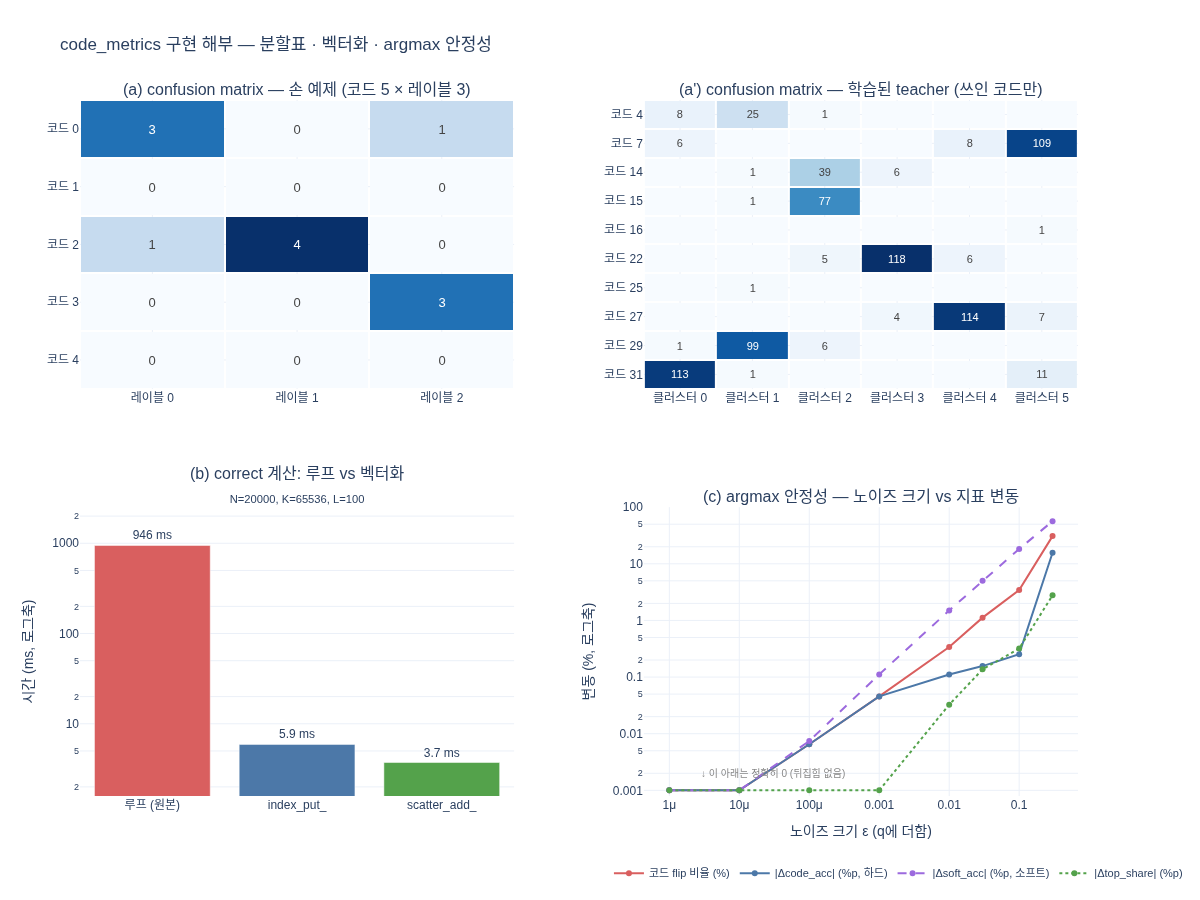

In [21]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "(a) confusion matrix — 손 예제 (코드 5 × 레이블 3)",
        "(a') confusion matrix — 학습된 teacher (쓰인 코드만)",
        f"(b) correct 계산: 루프 vs 벡터화<br><sub>N={N_BIG}, K={K_BIG}, L={L_BIG}</sub>",
        "(c) argmax 안정성 — 노이즈 크기 vs 지표 변동",
    ),
    specs=[[{"type": "heatmap"}, {"type": "heatmap"}],
           [{"type": "bar"}, {"type": "scatter"}]],
    vertical_spacing=0.17, horizontal_spacing=0.13,
)

z_toy = conf_toy.int().tolist()
fig.add_trace(go.Heatmap(
    z=z_toy, x=[f"레이블 {i}" for i in range(3)], y=[f"코드 {i}" for i in range(OUT_DIM)],
    colorscale="Blues", showscale=False, zmin=0,
    text=[[str(v) for v in row] for row in z_toy], texttemplate="%{text}",
    textfont={"size": 13}, xgap=2, ygap=2,
    hovertemplate="%{y} / %{x}: %{z}<extra></extra>",
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=z_real, x=[f"클러스터 {i}" for i in range(N_CLUSTERS)], y=[f"코드 {i}" for i in rows_used],
    colorscale="Blues", showscale=False, zmin=0,
    text=[[str(v) if v else "" for v in row] for row in z_real], texttemplate="%{text}",
    textfont={"size": 11}, xgap=2, ygap=2,
    hovertemplate="%{y} / %{x}: %{z}<extra></extra>",
), row=1, col=2)

names = list(timings.keys())
vals = [timings[n][0] * 1000 for n in names]
fig.add_trace(go.Bar(
    x=names, y=vals, marker_color=["#d95f5f", "#4c78a8", "#54a24b"],
    text=[f"{v:.0f} ms" if v > 20 else f"{v:.1f} ms" for v in vals],
    textposition="outside", showlegend=False,
), row=2, col=1)
fig.update_yaxes(type="log", title_text="시간 (ms, 로그축)", range=[0.2, 3.4], row=2, col=1)

FLOOR = 1e-3        # 로그축에 0을 못 그리므로 하한으로 눌러 표시
_f = lambda xs: [max(v * 100, FLOOR) for v in xs]
for ys, nm, col, dash in [
    (flip_rates, "코드 flip 비율 (%)", "#d95f5f", None),
    (d_acc, "|Δcode_acc| (%p, 하드)", "#4c78a8", None),
    (d_soft, "|Δsoft_acc| (%p, 소프트)", "#9c6ade", "dash"),
    (d_top, "|Δtop_share| (%p)", "#54a24b", "dot"),
]:
    fig.add_trace(go.Scatter(x=eps_grid, y=_f(ys), mode="lines+markers", name=nm,
                             line=dict(color=col, width=2, dash=dash)), row=2, col=2)
fig.update_xaxes(type="log", title_text="노이즈 크기 ε (q에 더함)", row=2, col=2)
fig.update_yaxes(type="log", title_text="변동 (%, 로그축)", range=[-3.1, 2.0], row=2, col=2)
fig.add_annotation(text="↓ 이 아래는 정확히 0 (뒤집힘 없음)", x=math.log10(3e-5), y=-2.7,
                   xref="x4", yref="y4", showarrow=False, font=dict(size=10, color="#888"))

fig.update_layout(
    height=900, width=1200, template="plotly_white",
    title_text="code_metrics 구현 해부 — 분할표 · 벡터화 · argmax 안정성",
    legend=dict(orientation="h", y=-0.09, x=0.53, font=dict(size=11)),
    margin=dict(t=100, b=100),
)
fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)

_out = os.path.join(
    os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else ".", "expy.png")
fig.write_image(_out, scale=2)
print("saved:", _out)
_show(fig)

## 정리

| 코드 조각 | 하는 일 | 왜 그렇게 |
|---|---|---|
| `q.argmax(-1)` | $(N,K)$ 소프트 → $(N,)$ 코드 | prototype 할당. margin 정보는 버려진다 |
| `bincount(minlength=q.shape[-1])` | 코드 사용량 히스토그램 | `.max()`만 쓰면 값은 무관하지만, 길이를 $K$로 고정해야 스텝 간 `stack`·인덱싱·히스토그램이 성립 |
| `codes.unique()` | 등장한 코드만 순회 | `range(K)`면 빈 코드에서 빈 텐서 `.max()` → RuntimeError |
| `labels[codes==c].bincount().max()` | 코드 내 최빈 레이블 개수 | 여기 `minlength`는 불필요(값만 씀). 단 레이블은 **0-기반 비음수** 필수, 동점은 무해 |
| `sum(... for c in ...)` | 파이썬 루프 | $K=32$면 무해, $K=65536$이면 150~350배 느림 → `index_put_`/`scatter_add_` 분할표로 대체 |

한 문장: `code_metrics`는 **코드 × 레이블 분할표를 코드별로 한 줄씩 만들어 행별 최대를 더하는 함수**이며,
`minlength`와 `unique()`는 그 표의 모양이 무너지지 않게 하는 두 개의 버팀목이다.